In [21]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from frank.io import load_uvtable, save_fit
from frank.radial_fitters import FrankFitter
from frank.geometry import FitGeometryGaussian
from frank.make_figs import make_quick_fig

In [22]:
from frank.geometry import FitGeometryFourierBessel

FF = FrankFitter(Rmax=1.6, N=250,
                 geometry=FitGeometryFourierBessel(Rmax=1.6, N=250),
                 alpha=1.05, weights_smooth=1e-4)
sol = FF.fit(u, v, vis, weights)
print(sol.geometry.inc, sol.geometry.PA, sol.geometry.dRA, sol.geometry.dDec)

C:\Users\fkurj\anaconda3\envs\myenv311\Lib\site-packages\frank\filter.py:175: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  tau = scipy.sparse.linalg.spsolve(Tij_pI, beta + np.log(pi))


9.999979428640513 10.000010317362417 0.008377954925823178 0.015784093376900593


In [23]:
from frank.geometry import FitGeometryFourierBessel

geom = FitGeometryFourierBessel(Rmax=1.6, N=250,
                                guess=[40., 155., 0., 0.],
                                verbose=True)

FF = FrankFitter(Rmax=1.6, N=250, geometry=geom,
                 alpha=1.05, weights_smooth=1e-4)
sol = FF.fit(u, v, vis, weights)
print(sol.geometry.inc, sol.geometry.PA, sol.geometry.dRA, sol.geometry.dDec)


      FitGeometryFourierBessel: Iteration 0, chi^2=1.37265726, inc=40.000 PA=155.000 dRA=0.00000 dDec=0.00000
      FitGeometryFourierBessel: Iteration 1, chi^2=1.37265726, inc=40.000 PA=155.000 dRA=0.00000 dDec=0.00000
      FitGeometryFourierBessel: Iteration 2, chi^2=1.37265725, inc=40.000 PA=155.000 dRA=0.00000 dDec=0.00000
      FitGeometryFourierBessel: Iteration 3, chi^2=1.37265725, inc=40.000 PA=155.000 dRA=0.00000 dDec=0.00000
      FitGeometryFourierBessel: Iteration 4, chi^2=1.37265725, inc=40.000 PA=155.000 dRA=0.00000 dDec=0.00000
      FitGeometryFourierBessel: Iteration 5, chi^2=1.36493348, inc=40.000 PA=155.000 dRA=0.00942 dDec=0.01456
      FitGeometryFourierBessel: Iteration 6, chi^2=1.36493349, inc=40.000 PA=155.000 dRA=0.00942 dDec=0.01456
      FitGeometryFourierBessel: Iteration 7, chi^2=1.36493350, inc=40.000 PA=155.000 dRA=0.00942 dDec=0.01456
      FitGeometryFourierBessel: Iteration 8, chi^2=1.36493348, inc=40.000 PA=155.000 dRA=0.00942 dDec=0.01456
      Fit

In [2]:
filepath = r"C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_uvtable.txt"


In [3]:
u, v, vis, weights = load_uvtable(filepath)

In [4]:
# ===== CELL 3 — frank fits (3 hyperparameter combos) =====
FF = FrankFitter(Rmax=1.6, N=250, geometry=FitGeometryGaussian(),
                 alpha=1.05, weights_smooth=1e-4)
sol = FF.fit(u, v, vis, weights)

FF_2 = FrankFitter(Rmax=1.6, N=250, geometry=FitGeometryGaussian(),
                   alpha=1.15, weights_smooth=1e-3)
sol_2 = FF_2.fit(u, v, vis, weights)

FF_3 = FrankFitter(Rmax=1.6, N=250, geometry=FitGeometryGaussian(),
                   alpha=1.25, weights_smooth=1e-1)
sol_3 = FF_3.fit(u, v, vis, weights)

C:\Users\fkurj\anaconda3\envs\myenv311\Lib\site-packages\frank\filter.py:175: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  tau = scipy.sparse.linalg.spsolve(Tij_pI, beta + np.log(pi))


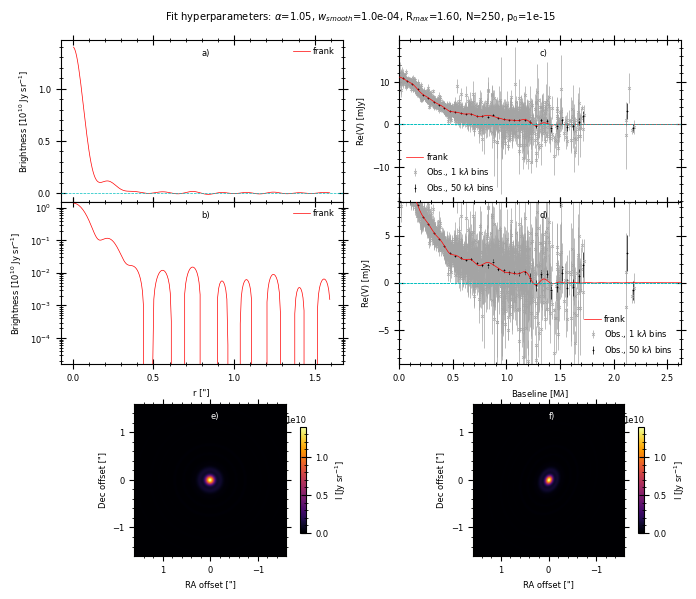

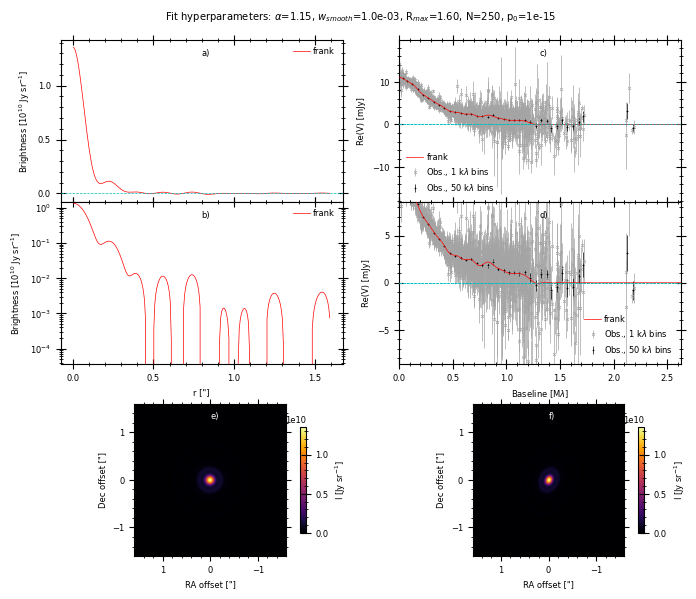

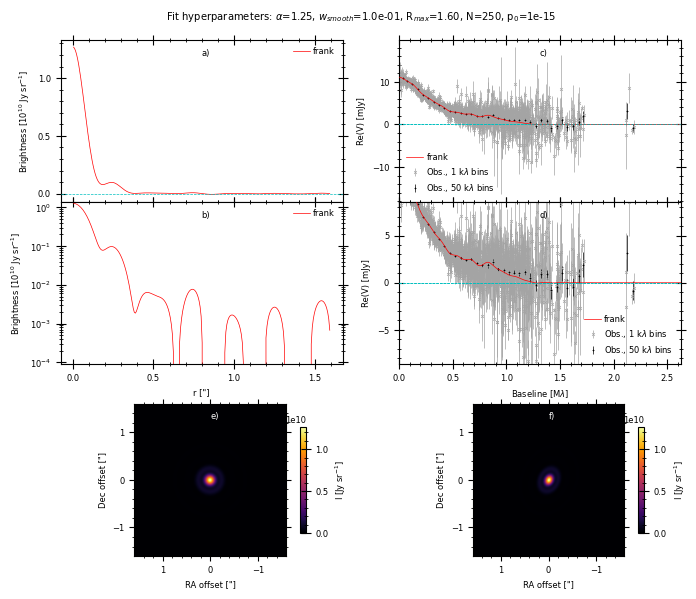

In [5]:
fig, axes = make_quick_fig(u, v, vis, weights, sol, bin_widths=[1e3, 5e4], force_style=True)
plt.savefig(filepath + '_frank_fit_quick.png')
fig, axes = make_quick_fig(u, v, vis, weights, sol_2, bin_widths=[1e3, 5e4], force_style=True)
plt.savefig(filepath + '_frank_fit_quick_2.png')
fig, axes = make_quick_fig(u, v, vis, weights, sol_3, bin_widths=[1e3, 5e4], force_style=True)
plt.savefig(filepath + '_frank_fit_quick_3.png')
plt.show()
save_fit(u, v, vis, weights, sol, prefix=filepath)

In [6]:
geom = FitGeometryGaussian()
geom.fit(u, v, vis, weights)
print('Fitted geometry: inc  = {:.2f} deg,\n\t\t PA   = {:.2f} deg,\n\t\t'
      ' dRA  = {:.2e} mas,\n\t\t dDec = {:.2e} mas'.format(geom.inc, geom.PA,
                                                           geom.dRA*1e3, geom.dDec*1e3))

Fitted geometry: inc  = 39.99 deg,
		 PA   = 155.06 deg,
		 dRA  = 8.19e+00 mas,
		 dDec = 1.58e+01 mas


In [7]:
inc = np.radians(geom.inc)
PA  = np.radians(geom.PA)
u_rot =  u * np.cos(PA) + v * np.sin(PA)
v_rot = -u * np.sin(PA) + v * np.cos(PA)
v_dep = v_rot / np.cos(inc)
baselines_dep = np.sqrt(u_rot**2 + v_dep**2)
max_baseline  = np.max(baselines_dep)
beam_arcsec = 206265.0 / max_baseline
beam_mas    = beam_arcsec * 1000
print(f"\nMax deprojected baseline : {max_baseline:.0f} wavelengths")
print(f"Beam FWHM                : {beam_mas:.1f} mas  ({beam_arcsec:.4f} arcsec)")


Max deprojected baseline : 2415346 wavelengths
Beam FWHM                : 85.4 mas  (0.0854 arcsec)


In [8]:
from astropy.io import fits
from frank.utilities import sweep_profile

r = sol.r
I = sol.I
inc_deg = geom.inc
PA_deg  = geom.PA

I2D, xmax, ymax = sweep_profile(r, I, project=True, phase_shift=True,
                                geom=geom, xmax=r.max(), ymax=r.max())

Npix = I2D.shape[0]
dpix = (2 * xmax) / Npix

hdu = fits.PrimaryHDU(data=I2D.astype(np.float32))
h = hdu.header
h['CTYPE1'] = 'RA---TAN'
h['CTYPE2'] = 'DEC--TAN'
h['CRPIX1'] = Npix / 2 + 1
h['CRPIX2'] = Npix / 2 + 1
h['CRVAL1'] = 0.0
h['CRVAL2'] = 0.0
h['CDELT1'] = -dpix / 3600.0
h['CDELT2'] =  dpix / 3600.0
h['BUNIT']  = 'Jy/sr'
h['BTYPE']  = 'Intensity'
h['INC']    = (inc_deg, 'Inclination [deg]')
h['PA']     = (PA_deg,  'Position angle [deg]')


outpath = r"C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_frank_image_shift.fits"
hdu.writeto(outpath, overwrite=True)
print(f"Saved: {outpath}")
print(f"Image size: {Npix}x{Npix} pixels, {dpix*1e3:.2f} mas/pixel")


Saved: C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_frank_image_shift.fits
Image size: 250x250 pixels, 12.75 mas/pixel


In [19]:
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from reproject import reproject_interp

observed_file = r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\ODISEA_C4_034_robust_0.5.pbcor.fits'
model_file    = r'C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_0.5_frank_convolved_shift.fits'
output_file   = r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\C4_034_0.5_residual.fits'

half_px = 0.5    

observed_hdu = fits.open(observed_file)[0]
model_hdu    = fits.open(model_file)[0]
observed_data = np.squeeze(observed_hdu.data)
model_data    = np.squeeze(model_hdu.data)
observed_wcs  = WCS(observed_hdu.header).celestial
pix = abs(observed_hdu.header.get('CDELT1', observed_hdu.header.get('CD1_1'))) * 3600.0

model_header_fixed = model_hdu.header.copy()
model_header_fixed['CRVAL1'] = observed_hdu.header['CRVAL1']
model_header_fixed['CRVAL2'] = observed_hdu.header['CRVAL2']
model_header_fixed['CRPIX1'] = model_hdu.header['CRPIX1'] - half_px
model_header_fixed['CRPIX2'] = model_hdu.header['CRPIX2'] - half_px

model_regridded, _ = reproject_interp(
    (model_data, WCS(model_header_fixed).celestial),
    observed_wcs, shape_out=observed_data.shape)

residual = observed_data - model_regridded
_, _, rms = sigma_clipped_stats(residual, sigma=3.0)

def centroid(img, thresh):
    m = np.where(np.isfinite(img) & (img > thresh), img, 0.0)
    yy, xx = np.indices(m.shape)
    return (m*xx).sum()/m.sum(), (m*yy).sum()/m.sum()

vr, vc = np.where(np.isfinite(model_regridded))
s = np.s_[vr.min():vr.max(), vc.min():vc.max()]
cx_o, cy_o = centroid(observed_data[s],   5*rms)
cx_m, cy_m = centroid(model_regridded[s], 5*rms)
print(f'rms = {rms*1e6:.1f} uJy/beam')
print(f'centroid offset: dx {(cx_o-cx_m)*pix*1e3:+.1f} mas, '
      f'dy {(cy_o-cy_m)*pix*1e3:+.1f} mas   (want ~0)')

out_header = observed_wcs.to_header()
out_header['BUNIT'] = observed_hdu.header.get('BUNIT', 'Jy/beam')
fits.writeto(output_file, residual, out_header, overwrite=True)
print('Residual saved to:', output_file)

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'.


rms = 28.8 uJy/beam
centroid offset: dx +0.1 mas, dy -0.4 mas   (want ~0)
Residual saved to: C:\Users\fkurj\Desktop\MSc_project\odisea_034\C4_034_0.5_residual.fits


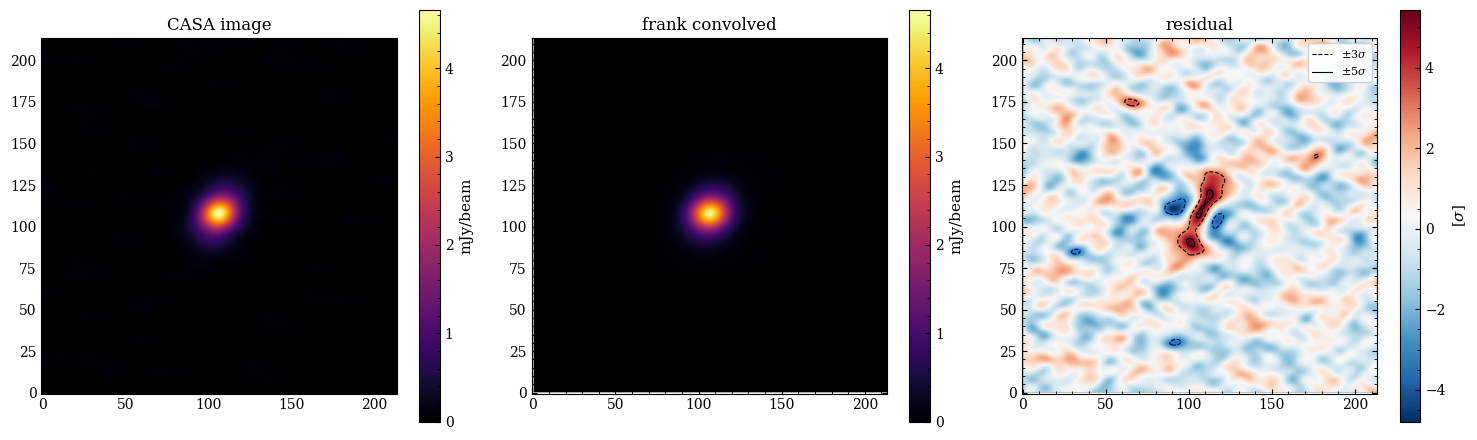

residual peak: 0.157 mJy/beam (5.43 sigma)


In [20]:
valid_mask = ~np.isnan(residual)
rows, cols = np.where(valid_mask & np.isfinite(model_regridded))
r0, r1 = rows.min()-1, rows.max()+1
c0, c1 = cols.min()-1, cols.max()+1
sub = residual[r0:r1, c0:c1]

obs_cut = observed_data[r0:r1, c0:c1]
mod_cut = model_regridded[r0:r1, c0:c1]
imax = np.nanmax(obs_cut) * 1e3               

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

for a, img, t in [(ax[0], obs_cut*1e3, 'CASA image'),
                  (ax[1], mod_cut*1e3, 'frank convolved')]:
    p = a.imshow(img, origin='lower', cmap='inferno', vmin=0, vmax=imax)
    a.set_title(t)
    plt.colorbar(p, ax=a, label='mJy/beam')

res_sigma = sub/rms
p = ax[2].imshow(res_sigma, origin='lower', cmap='RdBu_r',
                 vmin=np.nanmin(res_sigma), vmax=np.nanmax(res_sigma))

ax[2].contour(res_sigma, levels=[-3], colors='navy',
              linewidths=0.8, linestyles='dashed')
ax[2].contour(res_sigma, levels=[-5], colors='navy',
              linewidths=0.8, linestyles='solid')
ax[2].contour(res_sigma, levels=[3],  colors='black',
              linewidths=0.8, linestyles='dashed')
ax[2].contour(res_sigma, levels=[5],  colors='black',
              linewidths=0.8, linestyles='solid')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='black', lw=0.8, ls='dashed', label=r'$\pm3\sigma$'),
           Line2D([0], [0], color='black', lw=0.8, ls='solid',  label=r'$\pm5\sigma$')]
ax[2].legend(handles=handles, loc='upper right', fontsize=8,
             framealpha=0.9, handlelength=1.8)

ax[2].set_title('residual')
plt.colorbar(p, ax=ax[2], label=r'[$\sigma$]')
plt.tight_layout(); plt.show()

print(f'residual peak: {np.nanmax(np.abs(sub))*1e3:.3f} mJy/beam '
      f'({np.nanmax(np.abs(sub))/rms:.2f} sigma)')

In [11]:
observed_file = r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\ODISEA_C4_034_robust_-0.5.pbcor.fits'
model_file    = r'C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_-0.5_frank_convolved_shift.fits'
output_file   = r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\C4_034_-0.5_residual.fits'

observed_hdu = fits.open(observed_file)[0]
model_hdu    = fits.open(model_file)[0]
observed_data = np.squeeze(observed_hdu.data)
model_data    = np.squeeze(model_hdu.data)
observed_wcs  = WCS(observed_hdu.header).celestial

model_header_fixed = model_hdu.header.copy()
model_header_fixed['CRVAL1'] = observed_hdu.header['CRVAL1']
model_header_fixed['CRVAL2'] = observed_hdu.header['CRVAL2']
model_header_fixed['CRPIX1'] = model_hdu.header['CRPIX1'] - half_px   # validated value from CELL 8
model_header_fixed['CRPIX2'] = model_hdu.header['CRPIX2'] - half_px

model_regridded, _ = reproject_interp(
    (model_data, WCS(model_header_fixed).celestial),
    observed_wcs, shape_out=observed_data.shape)

residual = observed_data - model_regridded
_, _, rms = sigma_clipped_stats(residual, sigma=3.0)
print(f'rms = {rms*1e6:.1f} uJy/beam')

out_header = observed_wcs.to_header()
out_header['BUNIT'] = observed_hdu.header.get('BUNIT', 'Jy/beam')
fits.writeto(output_file, residual, out_header, overwrite=True)
print('Residual saved to:', output_file)


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'.


rms = 37.2 uJy/beam
Residual saved to: C:\Users\fkurj\Desktop\MSc_project\odisea_034\C4_034_-0.5_residual.fits


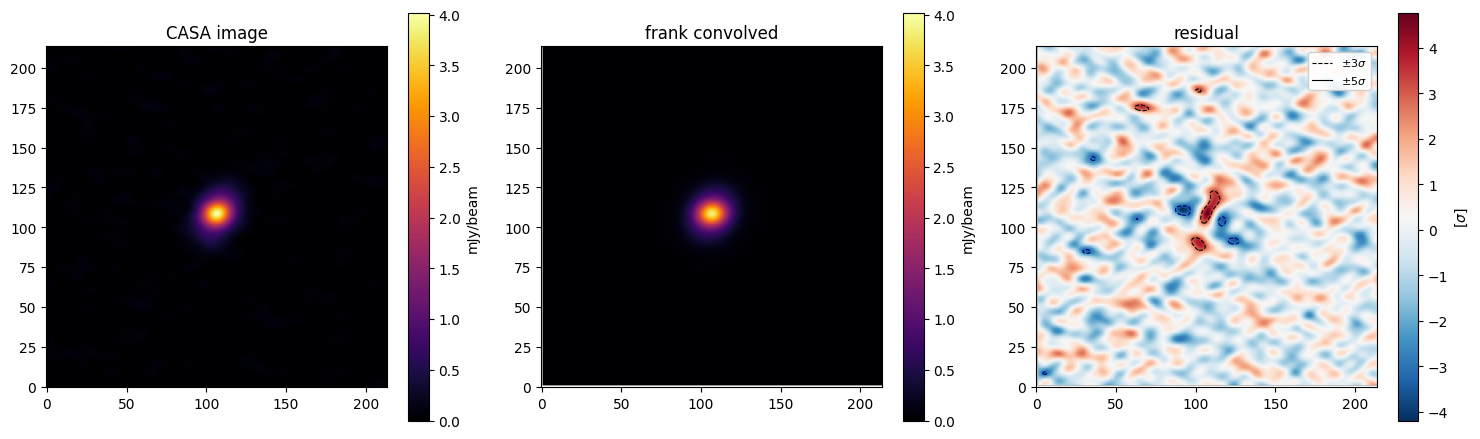

residual peak: 0.177 mJy/beam (4.76 sigma)


In [12]:
valid_mask = ~np.isnan(residual)
rows, cols = np.where(valid_mask & np.isfinite(model_regridded))
r0, r1 = rows.min()-1, rows.max()+1
c0, c1 = cols.min()-1, cols.max()+1
sub = residual[r0:r1, c0:c1]

obs_cut = observed_data[r0:r1, c0:c1]
mod_cut = model_regridded[r0:r1, c0:c1]
imax = np.nanmax(obs_cut) * 1e3               

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

for a, img, t in [(ax[0], obs_cut*1e3, 'CASA image'),
                  (ax[1], mod_cut*1e3, 'frank convolved')]:
    p = a.imshow(img, origin='lower', cmap='inferno', vmin=0, vmax=imax)
    a.set_title(t)
    plt.colorbar(p, ax=a, label='mJy/beam')

res_sigma = sub/rms
p = ax[2].imshow(res_sigma, origin='lower', cmap='RdBu_r',
                 vmin=np.nanmin(res_sigma), vmax=np.nanmax(res_sigma))

ax[2].contour(res_sigma, levels=[-3], colors='navy',
              linewidths=0.8, linestyles='dashed')
ax[2].contour(res_sigma, levels=[-5], colors='navy',
              linewidths=0.8, linestyles='solid')
ax[2].contour(res_sigma, levels=[3],  colors='black',
              linewidths=0.8, linestyles='dashed')
ax[2].contour(res_sigma, levels=[5],  colors='black',
              linewidths=0.8, linestyles='solid')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='black', lw=0.8, ls='dashed', label=r'$\pm3\sigma$'),
           Line2D([0], [0], color='black', lw=0.8, ls='solid',  label=r'$\pm5\sigma$')]
ax[2].legend(handles=handles, loc='upper right', fontsize=8,
             framealpha=0.9, handlelength=1.8)

ax[2].set_title('residual')
plt.colorbar(p, ax=ax[2], label=r'[$\sigma$]')
plt.tight_layout(); plt.show()

print(f'residual peak: {np.nanmax(np.abs(sub))*1e3:.3f} mJy/beam '
      f'({np.nanmax(np.abs(sub))/rms:.2f} sigma)')

In [13]:
R_IN, R_OUT = 1.2, 1.8

def measure_rms(image, header, r_in, r_out):
    ny, nx = image.shape
    pix = abs(header.get('CDELT1', header.get('CD1_1'))) * 3600.0
    yy, xx = np.mgrid[:ny, :nx]
    rad  = np.hypot(xx-(nx-1)/2., yy-(ny-1)/2.) * pix
    ring = (rad >= r_in) & (rad <= r_out) & np.isfinite(image)
    if ring.sum() < 100:
        raise ValueError(f"only {ring.sum()} px in annulus")
    vals = image[ring]
    keep = np.abs(vals - np.median(vals)) < 5*np.std(vals)
    print(f"annulus {r_in}\"-{r_out}\": {ring.sum()} px, {(~keep).sum()} clipped")
    return np.std(vals[keep])

def compute_nai(data, model, resid, rms, snr_cut=5.0):
    """Curone+2025 ApJL 984:L9 Eq. 6"""
    assert data.shape == model.shape == resid.shape, "grid mismatch"
    good = np.isfinite(data) & np.isfinite(model) & np.isfinite(resid)
    mask = good & (data >= snr_cut * rms)
    if mask.sum() == 0:
        raise ValueError(f"no pixels above SNR {snr_cut}")
    return np.abs(resid[mask]).sum() / np.abs(model[mask]).sum(), mask

runs = [
    ('0.5',  r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\ODISEA_C4_034_robust_0.5.pbcor.fits',
             r'C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_0.5_frank_convolved_shift.fits',
             r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\C4_034_0.5_residual.fits'),
    ('-0.5', r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\ODISEA_C4_034_robust_-0.5.pbcor.fits',
             r'C:\Users\fkurj\Desktop\MSc_project\odisea_data\ODISEA_C4_034_-0.5_frank_convolved_shift.fits',
             r'C:\Users\fkurj\Desktop\MSc_project\odisea_034\C4_034_-0.5_residual.fits'),
]

nai_results = {}
for rob, observed_file, model_file, residual_file in runs:
    observed_hdu = fits.open(observed_file)[0]
    model_hdu    = fits.open(model_file)[0]
    observed_data = np.squeeze(observed_hdu.data)
    model_data    = np.squeeze(model_hdu.data)
    observed_wcs  = WCS(observed_hdu.header).celestial

    model_header_fixed = model_hdu.header.copy()
    model_header_fixed['CRVAL1'] = observed_hdu.header['CRVAL1']
    model_header_fixed['CRVAL2'] = observed_hdu.header['CRVAL2']
    model_header_fixed['CRPIX1'] = model_hdu.header['CRPIX1'] - half_px
    model_header_fixed['CRPIX2'] = model_hdu.header['CRPIX2'] - half_px

    model_regridded, _ = reproject_interp(
        (model_data, WCS(model_header_fixed).celestial),
        observed_wcs, shape_out=observed_data.shape)

    residual = np.squeeze(fits.open(residual_file)[0].data)   # written post-fix by cells 8/10

    print(f"\n--- robust {rob} ---")
    print("BUNIT  data:", observed_hdu.header.get('BUNIT'),
          " model:", model_hdu.header.get('BUNIT'))
    rms = measure_rms(observed_data, observed_hdu.header, R_IN, R_OUT)
    nai, mask = compute_nai(observed_data, model_regridded, residual, rms)
    print(f"rms  : {rms*1e6:.1f} uJy/beam   (peak SNR {np.nanmax(observed_data)/rms:.0f})")
    print(f"mask : {mask.sum()} px above SNR 5")
    print(f"NAI  : {nai:.4f}")
    nai_results[rob] = dict(nai=nai, rms=rms, npix=int(mask.sum()))

print("\n" + "="*40)
for rob, r_ in nai_results.items():
    print(f"robust {rob:>5}   NAI = {r_['nai']:.4f}   "
          f"rms = {r_['rms']*1e6:.1f} uJy/beam   {r_['npix']} px")

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'.



--- robust 0.5 ---
BUNIT  data: Jy/beam  model: Jy/beam
annulus 1.2"-1.8": 25136 px, 0 clipped
rms  : 28.0 uJy/beam   (peak SNR 167)
mask : 2000 px above SNR 5
NAI  : 0.0718


Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'.



--- robust -0.5 ---
BUNIT  data: Jy/beam  model: Jy/beam
annulus 1.2"-1.8": 25136 px, 0 clipped
rms  : 36.2 uJy/beam   (peak SNR 111)
mask : 1428 px above SNR 5
NAI  : 0.0719

robust   0.5   NAI = 0.0718   rms = 28.0 uJy/beam   2000 px
robust  -0.5   NAI = 0.0719   rms = 36.2 uJy/beam   1428 px


In [14]:
DISTANCE = 137.53

def disc_radii(sol, fractions=(0.68, 0.90)):
    """Radii enclosing given flux fractions, integrating to the first zero crossing."""
    r, I = sol.r, sol.I
    neg  = np.where(I <= 0)[0]
    stop = neg[0] if len(neg) else len(I)
    rr, II = r[:stop], I[:stop]
    rad = rr * np.pi / (180 * 3600)
    cum = np.concatenate([[0], np.cumsum(
        np.pi * (II[1:]*rad[1:] + II[:-1]*rad[:-1]) * np.diff(rad))])
    return cum[-1], [np.interp(f * cum[-1], cum, rr) for f in fractions], rr[-1]

print('{:<8}{:>6}{:>9}{:>10}{:>10}{:>11}{:>10}'.format(
    'run', 'alpha', 'wsmooth', 'R68 (au)', 'R90 (au)', 'flux(mJy)', 'trunc(as)'))
results = {}
for name, s_, a, w_ in [('sol', sol, 1.05, 1e-4),
                        ('sol_2', sol_2, 1.15, 1e-3),
                        ('sol_3', sol_3, 1.25, 1e-1)]:
    tot, (R68, R90), rt = disc_radii(s_)
    results[name] = (R68, R90)
    print('{:<8}{:>6}{:>9.0e}{:>10.2f}{:>10.2f}{:>11.2f}{:>10.3f}'.format(
        name, a, w_, R68*DISTANCE, R90*DISTANCE, tot*1e3, rt))

spread  = np.ptp([v[0] for v in results.values()]) / np.mean([v[0] for v in results.values()])
R68_ref = results['sol'][0]
print('\nR68 spread across hyperparameters: {:.1f}%'.format(100*spread))
print('R68 = {:.4f} as  vs beam {:.4f} as  (ratio {:.2f})'.format(
    R68_ref, beam_arcsec, R68_ref/beam_arcsec))
if spread > 0.20 or R68_ref < beam_arcsec:
    print('-> under-resolved / unstable: quote as an upper limit')
else:
    print('-> resolved and stable')

run      alpha  wsmooth  R68 (au)  R90 (au)  flux(mJy) trunc(as)
sol       1.05    1e-04     26.90     39.47      13.58     0.439
sol_2     1.15    1e-03     27.11     39.23      13.60     0.451
sol_3     1.25    1e-01     28.24     41.87      14.02     0.624

R68 spread across hyperparameters: 4.9%
R68 = 0.1956 as  vs beam 0.0854 as  (ratio 2.29)
-> resolved and stable


wrote C:\Users\fkurj\Desktop\MSc_project\figures\C4_034_profile.pdf | axes in figure: 1


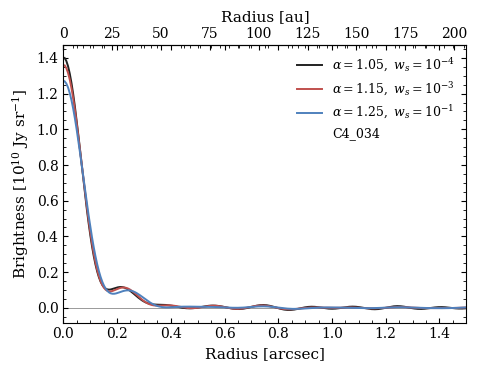

In [15]:
import os
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 10, 'axes.labelsize': 11,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'axes.linewidth': 0.8, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
FIGDIR = r"C:\Users\fkurj\Desktop\MSc_project\figures"
os.makedirs(FIGDIR, exist_ok=True)
SOURCE = 'C4_034'
DISTANCE = 137.53
RMAX_PLOT = 1.5

fig_prof, ax = plt.subplots(figsize=(5.2, 3.6))
for s, lab, c in [(sol,   r'$\alpha=1.05,\ w_s=10^{-4}$', '#222222'),
                  (sol_2, r'$\alpha=1.15,\ w_s=10^{-3}$', '#c0504d'),
                  (sol_3, r'$\alpha=1.25,\ w_s=10^{-1}$', '#4f81bd')]:
    ax.plot(s.r, s.I/1e10, lw=1.4, color=c, label=lab)
ax.plot([], [], ' ', label=SOURCE)
ax.axhline(0, color='0.6', lw=0.7, zorder=0)
ax.set_xlim(0, RMAX_PLOT)
ax.set_xlabel('Radius [arcsec]')
ax.set_ylabel(r'Brightness [$10^{10}$ Jy sr$^{-1}$]')
ax.legend(frameon=False, fontsize=9)
secax = ax.secondary_xaxis('top', functions=(lambda x: x*DISTANCE,
                                             lambda x: x/DISTANCE))
secax.set_xlabel('Radius [au]')

out = os.path.join(FIGDIR, SOURCE + '_profile.pdf')
fig_prof.savefig(out)
print('wrote', out, '| axes in figure:', len(fig_prof.axes))
plt.show()

C:\Users\fkurj\AppData\Local\Temp\ipykernel_22308\898139781.py:36: UserWarning: The following kwargs were not used by contour: 'lw'
  ax2.contour(rs, levels=[-5,-3], colors='k', lw=0.6, linestyles=['solid','dashed'], extent=ext)
C:\Users\fkurj\AppData\Local\Temp\ipykernel_22308\898139781.py:37: UserWarning: The following kwargs were not used by contour: 'lw'
  ax2.contour(rs, levels=[3,5],  colors='k', lw=0.6, linestyles=['dashed','solid'], extent=ext)


wrote C:\Users\fkurj\Desktop\MSc_project\figures\C4_034_residual_robust0.5.pdf | axes in figure: 5


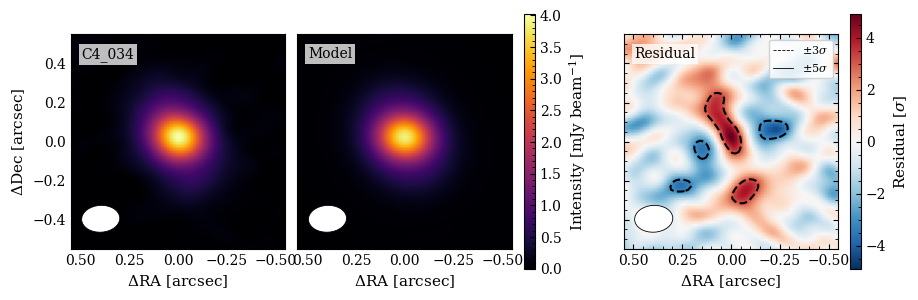

In [16]:
import os
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.rcParams.update({
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 10, 'axes.labelsize': 11,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'axes.linewidth': 0.8, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

FOV = 0.55          
h   = observed_hdu.header
bmaj, bmin, bpa = h['BMAJ']*3600, h['BMIN']*3600, h['BPA']

ny, nx = observed_data.shape
ext = np.array([-nx/2, nx/2, -ny/2, ny/2]) * pix

fig_res = plt.figure(figsize=(10.2, 3.3))
gs  = fig_res.add_gridspec(1, 6, width_ratios=[1, 1, 0.05, 0.30, 1, 0.05], wspace=0.10)
ax0, ax1 = fig_res.add_subplot(gs[0]), fig_res.add_subplot(gs[1])
cax1     = fig_res.add_subplot(gs[2])
ax2      = fig_res.add_subplot(gs[4])
cax2     = fig_res.add_subplot(gs[5])

vmax = np.nanmax(observed_data)*1e3
for a, img in [(ax0, observed_data*1e3), (ax1, model_regridded*1e3)]:
    im = a.imshow(img, origin='lower', extent=ext, cmap='inferno', vmin=0, vmax=vmax)
fig_res.colorbar(im, cax=cax1).set_label(r'Intensity [mJy beam$^{-1}$]')

rs  = residual/rms
lim = np.nanmax(np.abs(rs))
imr = ax2.imshow(rs, origin='lower', extent=ext, cmap='RdBu_r', vmin=-lim, vmax=lim)
ax2.contour(rs, levels=[-5,-3], colors='k', lw=0.6, linestyles=['solid','dashed'], extent=ext)
ax2.contour(rs, levels=[3,5],  colors='k', lw=0.6, linestyles=['dashed','solid'], extent=ext)
fig_res.colorbar(imr, cax=cax2).set_label(r'Residual [$\sigma$]')
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='k', lw=0.6, ls='dashed', label=r'$\pm3\sigma$'),
           Line2D([0], [0], color='k', lw=0.6, ls='solid',  label=r'$\pm5\sigma$')]
ax2.legend(handles=handles, loc='upper right', fontsize=8,
           frameon=True, framealpha=0.85, handlelength=1.8)
for a, ttl in zip([ax0,ax1,ax2], ['C4_034','Model','Residual']):
    a.set_xlim(FOV, -FOV); a.set_ylim(-FOV, FOV)
    a.set_xlabel(r'$\Delta$RA [arcsec]')
    a.add_patch(Ellipse((FOV*0.72, -FOV*0.72), bmin, bmaj, angle=bpa,
                        fc='w', ec='k', lw=0.6))
    a.text(0.05, 0.94, ttl, transform=a.transAxes, fontsize=10, va='top',
           bbox=dict(fc='w', ec='none', alpha=0.75, pad=2))
ax0.set_ylabel(r'$\Delta$Dec [arcsec]')
ax1.set_yticklabels([]); ax2.set_yticklabels([])

out_res = os.path.join(FIGDIR, SOURCE + '_residual_robust0.5.pdf')
fig_res.savefig(out_res)
print('wrote', out_res, '| axes in figure:', len(fig_res.axes))
plt.show()